# SGD with PyTorch | California Housing

Same idea as the manual notebooks, but we let PyTorch do the work:
`nn.Linear` holds the weights + bias, `torch.optim.SGD` does the update,
and autograd computes the gradients for us (no hand-derived formulas).

Dataset: California housing, 8 features, target = median house value.

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
# load data: x = 8 features, y = median house value
x, y = fetch_california_housing(return_X_y=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# scale features to mean 0 / std 1 -- without this SGD diverges (features have wildly different ranges)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# convert to tensors. y reshaped to (N, 1) to match the model output
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print(x_train.shape, y_train.shape)

torch.Size([16512, 8]) torch.Size([16512, 1])


In [10]:
# model: one linear layer, 8 inputs -> 1 output (this holds w and b)
model = nn.Linear(8, 1)

loss_fn = nn.MSELoss()                                    # mean squared error
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # SGD does the weight update

In [11]:
loss_indx = []

# 3000 steps so the model actually learns (100 steps barely sees the 16k rows)
for step in range(3000):
    # pick one random training sample (stochastic = one point per step)
    k = torch.randint(0, len(x_train), (1,))
    x_batch = x_train[k]
    y_batch = y_train[k]

    y_pred = model(x_batch)          # forward pass
    loss = loss_fn(y_pred, y_batch)  # how wrong

    optimizer.zero_grad()  # clear old gradients
    loss.backward()        # autograd computes new gradients
    optimizer.step()       # SGD updates w and b

    loss_indx.append(loss.item())

print(f"last step loss: {loss_indx[-1]:.4f}")

last step loss: 0.7026


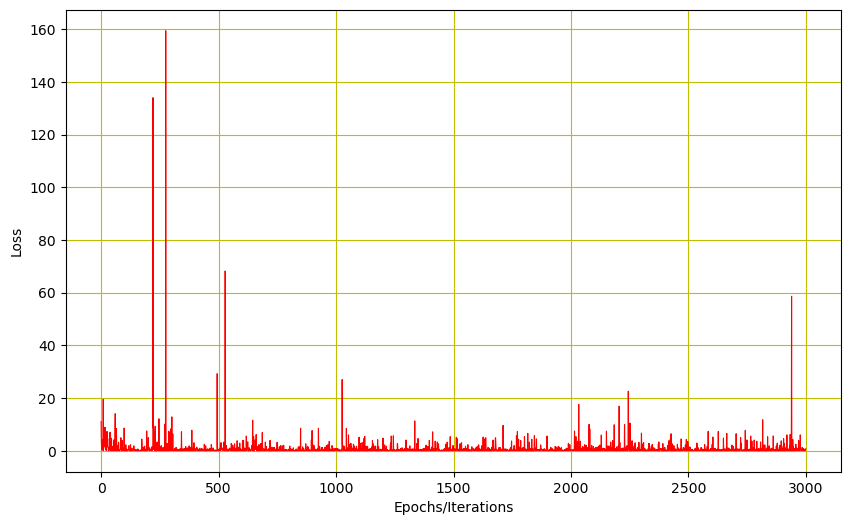

In [13]:
# per-step loss -- noisy because each step sees only one random point
plt.figure(figsize=(10, 6))
plt.plot(loss_indx, 'r', lw=0.8)
plt.xlabel('Epochs/Iterations')
plt.ylabel('Loss')
plt.grid(True, color='y')
plt.show()

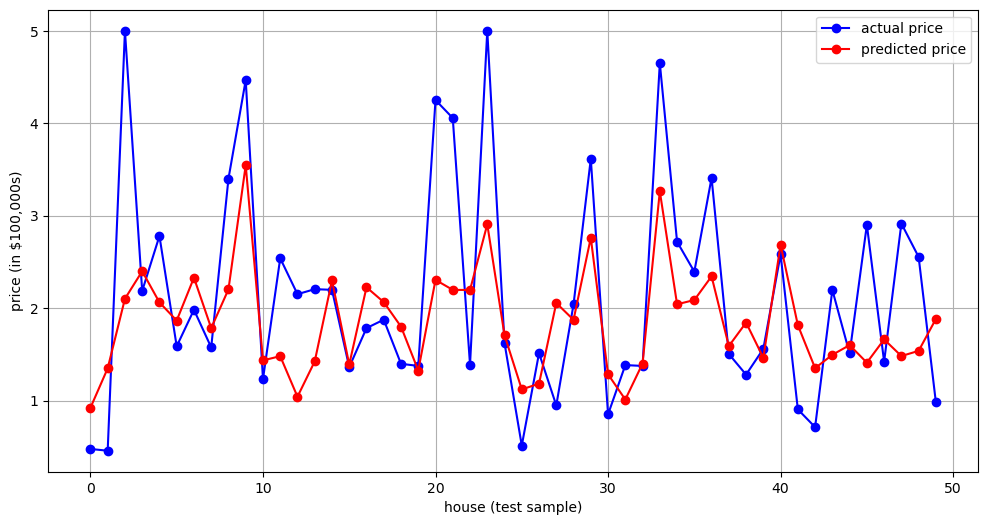

In [7]:
# how well it predicts: actual vs predicted price for 50 test houses
with torch.no_grad():
    pred = model(x_test).numpy().ravel()
actual = y_test.numpy().ravel()

n = 50  # just the first 50 houses, otherwise too crowded to read
houses = np.arange(n)

plt.figure(figsize=(12, 6))
plt.plot(houses, actual[:n], 'o-', label='actual price', color='blue')
plt.plot(houses, pred[:n], 'o-', label='predicted price', color='red')
plt.xlabel('house (test sample)')
plt.ylabel('price (in $100,000s)')
plt.legend()
plt.grid(True)
plt.show()